In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays

## Loading & Checking the Data

Source: https://www.entsoe.eu/data/power-stats/

Years: 2019-2025

In [2]:
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

In [3]:
dfs = []

In [4]:
for year in years:
    if year in [2021, 2022]:
        loaded = pd.read_csv(f'.\\data\\{year}.csv', sep=";")
    else:
        loaded = pd.read_csv(f'.\\data\\{year}.csv', sep="\t")
    loaded_at = loaded[loaded["CountryCode"] == "AT"].copy()
    loaded_at["DateUTC"] = pd.to_datetime(loaded_at["DateUTC"], dayfirst = True)
    loaded_at = loaded_at.sort_values("DateUTC")
    dfs.append(loaded_at[["DateUTC", "Value"]])
    

In [5]:
len(dfs)

7

In [6]:
data = pd.concat(dfs)
data = data.sort_values("DateUTC")
data = data.set_index("DateUTC")
data = data.groupby(data.index).mean() #Removes Duplicate Entries on Summertime change

In [7]:
data.isna().sum()

Value    0
dtype: int64

In [8]:
data.head()

,Value
DateUTC,
2019-01-01 00:00:00,5852.5
2019-01-01 01:00:00,5619.2
2019-01-01 02:00:00,5323.9
2019-01-01 03:00:00,5273.3
2019-01-01 04:00:00,5439.0


In [9]:
print(data.index.min())
print(data.index.max())
print(len(data))
print(data.index.inferred_freq)

2019-01-01 00:00:00
2025-09-30 23:00:00
59154
None


In [10]:
data = data.asfreq("h")

In [11]:
print(data.index.inferred_freq)

h


In [12]:
data.isna().sum()

Value    6
dtype: int64

In [13]:
data.index.duplicated().sum()

np.int64(0)

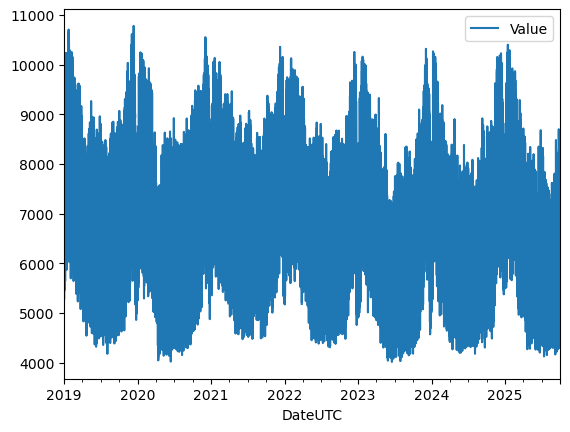

In [14]:
data.plot()
plt.show()

## Creating Features

In [15]:
data["weekday"] = data.index.day_name()
data["day"] = data.index.day
data["hour"] = data.index.hour
data["month"] = data.index.month

In [16]:
data["lag_1"] = data["Value"].shift(1)
data["lag_24"] = data["Value"].shift(24)
data["lag_168"] = data["Value"].shift(168)

In [17]:
data["rolling_mean_24"] = data["Value"].shift(1).rolling(window = 24).mean()
data["rolling_std_24"] = data["Value"].shift(1).rolling(window = 24).std()
data["rolling_mean_168"] = data["Value"].shift(1).rolling(window = 168).mean()
data["rolling_std_168"] = data["Value"].shift(1).rolling(window = 168).std()

In [18]:
at_holidays = holidays.Austria(years = years)

In [19]:
list(at_holidays.keys())[0]

datetime.date(2019, 1, 1)

In [20]:
type(list(at_holidays.keys())[0])

datetime.date

In [21]:
data["is_weekend"] = data["weekday"].isin(["Saturday", "Sunday"]).astype(int)
data["is_holiday"] = [ 1 if ts.date() in at_holidays else 0 for ts in data.index]
data["is_free_day"] = ((data["is_holiday"] == 1) | (data["is_weekend"] == 1)).astype(int)
data = data.drop(columns=["is_weekend", "is_holiday"])

In [22]:
data = data.dropna()

In [23]:
data.head()

,Value,weekday,day,hour,month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,is_free_day
DateUTC,,,,,,,,,,,,,
2019-01-08 00:00:00,6868.8,Tuesday,8,0,1,7071.8,6089.6,5852.5,8526.266667,1493.721086,7690.789881,1278.653125,0
2019-01-08 01:00:00,6744.7,Tuesday,8,1,1,6868.8,5961.5,5619.2,8558.733333,1446.167574,7696.839286,1272.292232,0
2019-01-08 02:00:00,6597.1,Tuesday,8,2,1,6744.7,5875.0,5323.9,8591.366667,1392.866180,7703.538690,1264.224315,0
2019-01-08 03:00:00,6693.9,Tuesday,8,3,1,6597.1,6073.5,5273.3,8621.454167,1338.371463,7711.117262,1253.645744,0
2019-01-08 04:00:00,7379.1,Tuesday,8,4,1,6693.9,6894.8,5439.0,8647.304167,1292.214736,7719.573214,1241.839430,0


In [26]:
data.describe()

,Value,day,hour,month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,is_free_day
count,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000,57978.000000
mean,6906.943573,15.772258,11.500983,6.420159,6906.962272,6907.512367,6907.167398,6907.088513,932.337327,6908.070670,1108.707198,0.313257
std,1334.187899,8.688710,6.921930,3.397348,1334.188337,1335.054834,1335.235099,943.158927,248.402731,736.091127,137.238831,0.463822
min,4013.500000,1.000000,0.000000,1.000000,4013.500000,4013.500000,4013.500000,4621.845833,222.435517,5529.927381,682.235912,0.000000
25%,5835.025000,8.000000,6.000000,3.000000,5835.100000,5835.025000,5833.800000,6289.633333,741.395743,6325.538839,1008.079816,0.000000
50%,6851.200000,16.000000,12.000000,6.000000,6851.200000,6851.300000,6851.200000,6890.504167,960.228702,6752.705952,1120.758968,0.000000
75%,7855.200000,23.000000,18.000000,9.000000,7855.200000,7856.375000,7856.100000,7501.920833,1126.846214,7522.419792,1213.038301,1.000000
max,10779.000000,31.000000,23.000000,12.000000,10779.000000,10779.000000,10779.000000,9410.525000,1785.494490,8708.580952,1561.343377,1.000000


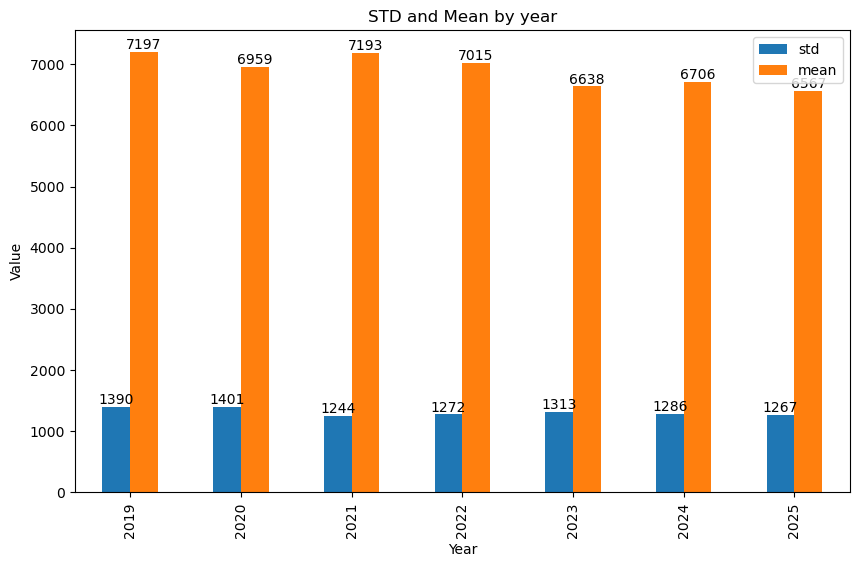

In [24]:
df = data.copy()
df["year"] = df.index.year

ax = df.groupby("year")["Value"].agg(["std", "mean"]).plot(kind="bar", figsize=(10,6))
for container in ax.containers:
    ax.bar_label(container, fmt="%.f")
plt.title("STD and Mean by year")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()